In [46]:
# %% Setup
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoid libomp double-init abort (numpy and torch both bundle OpenMP on macOS)
os.environ.setdefault("OMP_NUM_THREADS", "1")           # avoids an OMP pthread_mutex_init segfault during inference on macOS

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import torch
from timesfm3 import TimesFM3Forecaster

# TimesFM 3.0 ships as the `timesfm3` package inside the `timesfm` distribution (pip install
# "timesfm[torch]") - the `timesfm` package itself is the older 2.5 model. Weights download from
# the Hugging Face hub on first use, no token needed, but note they are released under a
# non-commercial licence (the source is Apache-2.0) - fine for research, not for production.
device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = TimesFM3Forecaster.from_pretrained("google/timesfm-3.0-pytorch", device=device)
print(f"Loaded TimesFM 3.0 on {device}")

Loaded TimesFM 3.0 on cpu


In [47]:
# %% Load and align data: states (targets) + exogenous inputs (covariates)
STATE_COLUMNS = {"C_A": "C_A", "T": "T", "T_C": "T_C", "h": "h", "Q_vec": "Q", "Q_c_vec": "Qc"}
EXOG_COLUMNS = {"F1": "E_R", "F2": "U_Ac", "F4": "T_F", "F5": "C_F", "F6": "T_CF", "F7": "Q_F"}

DOWNSAMPLE = 20  # must match FACTOR in CSTR-Downsample.ipynb

with h5py.File(f"CSTR_SimulationData_ds{DOWNSAMPLE}.h5", "r") as f:
    data = {col: f[key][:, 0] for key, col in STATE_COLUMNS.items()}
    n = len(data["C_A"])

# state[j] corresponds to raw input index 1 + j, strided by DOWNSAMPLE to match the full-resolution input file
idx = 1 + np.arange(n) * DOWNSAMPLE

with h5py.File("CSTR_InputVectors.h5", "r") as f:
    for key, col in EXOG_COLUMNS.items():
        data[col] = f[key][idx, 0]
    flags = {key: f[f"{key}.plt"][idx] for key in EXOG_COLUMNS}

print(EXOG_COLUMNS.keys())

df = pd.DataFrame(data)
df["item_id"] = "cstr"
df["timestamp"] = pd.date_range("2026-01-01", periods=n, freq=f"{DOWNSAMPLE}s")
df = df[["item_id", "timestamp"] + list(STATE_COLUMNS.values()) + list(EXOG_COLUMNS.values())]
df.head()

dict_keys(['F1', 'F2', 'F4', 'F5', 'F6', 'F7'])


,item_id,timestamp,C_A,T,T_C,h,Q,Qc,E_R,U_Ac,T_F,C_F,T_CF,Q_F
0,cstr,2026-01-01 00:00:00,0.042680,402.235112,345.203306,0.600000,1.666657,0.249995,8750.0,833.333333,319.974511,0.999984,300.000496,1.666687
1,cstr,2026-01-01 00:00:20,0.036173,402.747833,344.968421,0.600167,1.666310,0.263921,8750.0,833.333333,319.934461,0.999772,300.017229,1.666107
2,cstr,2026-01-01 00:00:40,0.038006,401.882899,344.616651,0.600123,1.665862,0.256489,8750.0,833.333333,319.869430,0.999928,300.021288,1.665757
3,cstr,2026-01-01 00:01:00,0.038446,401.731625,344.730512,0.600103,1.666388,0.252465,8750.0,833.333333,319.971990,1.000179,300.026596,1.665872
4,cstr,2026-01-01 00:01:20,0.038290,401.815817,344.853108,0.600071,1.665903,0.252479,8750.0,833.333333,320.045624,0.999929,300.002199,1.665687


In [48]:
# %% Pick a forecast window
events = []
for key in EXOG_COLUMNS:
    active = np.where(flags[key] > 0)[0]
    if len(active) == 0:
        continue
    breaks = np.where(np.diff(active) > 1)[0]
    starts = np.concatenate([[active[0]], active[breaks + 1]])
    ends = np.concatenate([active[breaks], [active[-1]]])
    events += [(s, e, EXOG_COLUMNS[key]) for s, e in zip(starts, ends)]
events.sort()

EVENT_INDEX = 12     # which fault event to forecast across, in time order; -1 = last = most available context
BUFFER = 100          # samples of steady state before the fault kept inside the forecast window (not the context)
PLOT_LEAD_IN = 500    # samples of history shown in the plot before the forecast - display only, doesn't affect what the model sees
HORIZON = None        # forecast horizon in samples - set an int yourself, or leave None to size it to the event (capped below)

event_start, event_end, event_name = events[EVENT_INDEX]
SPLIT = max(event_start - BUFFER, 0)          # everything before this is context
context_available = SPLIT
context_used = min(context_available, pipeline.global_context)
if HORIZON is None:
    HORIZON = min((event_end - SPLIT) + 1000, n - SPLIT)   # TimesFM 3.0 stitches output patches, so no fixed max prediction length

print(
    f"Forecasting across the {event_name} event: {context_available} samples of context available "
    f"({context_used} will actually be used - model max is {pipeline.global_context}), horizon = {HORIZON} steps"
)

Forecasting across the U_Ac event: 2456 samples of context available (2456 will actually be used - model max is 15360), horizon = 1281 steps


In [49]:
# %% Run TimesFM 3.0 with past states + past-and-future exogenous inputs
# TimesFM 3.0 is natively multivariate: the 6 states go in as target variates of a single
# (variates, context) array and the exogenous inputs as past-and-future covariate channels, so one
# call covers all 6 states - unlike TabPFN-TS, which needs a regression call per series.
# Context is sliced to context_used here rather than left to the model's internal truncation, so
# the covariate array is guaranteed to stay aligned with the target.
QUANTILES = [0.1, 0.5, 0.9]

context_df = df.iloc[SPLIT - context_used:SPLIT].copy()
future_df = df.iloc[SPLIT:SPLIT + HORIZON][["item_id", "timestamp"] + list(EXOG_COLUMNS.values())].copy()
truth_df = df.iloc[SPLIT:SPLIT + HORIZON].copy()

target = context_df[list(STATE_COLUMNS.values())].to_numpy(dtype=np.float32).T        # (6, context_used)
past_future_cov = np.concatenate([                                                     # (6, context_used + HORIZON)
    context_df[list(EXOG_COLUMNS.values())].to_numpy(dtype=np.float32),
    future_df[list(EXOG_COLUMNS.values())].to_numpy(dtype=np.float32),
]).T

out = pipeline.predict(
    target,
    horizon=HORIZON,
    past_future_covariates=past_future_cov,
    return_quantiles=True,
)   # out.forecast: (6, HORIZON) median, out.quantiles: (6, HORIZON, 9) for deciles 0.1 .. 0.9


q_index = {q: pipeline.config.quantiles.index(q) for q in QUANTILES}   # deciles come back in a fixed order
print(q_index)
pred_df = pd.concat(
    [
        pd.DataFrame({
            "item_id": "cstr",
            "timestamp": truth_df["timestamp"].values,
            "target_name": col,
            "predictions": out.forecast[v],
            **{str(q): out.quantiles[v, :, i] for q, i in q_index.items()},
        })
        for v, col in enumerate(STATE_COLUMNS.values())
    ],
    ignore_index=True,
)


pred_df.head()

{0.1: 0, 0.5: 4, 0.9: 8}


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,cstr,2026-01-01 13:38:40,C_A,0.046859,0.046823,0.046859,0.046893
1,cstr,2026-01-01 13:39:00,C_A,0.046861,0.046758,0.046861,0.047033
2,cstr,2026-01-01 13:39:20,C_A,0.046853,0.046684,0.046853,0.047045
3,cstr,2026-01-01 13:39:40,C_A,0.046885,0.046651,0.046885,0.047096
4,cstr,2026-01-01 13:40:00,C_A,0.046857,0.046646,0.046857,0.047153


C_A: MAE = 0.0015106
T: MAE = 0.58742
T_C: MAE = 1.4211
h: MAE = 4.0484e-05
Q: MAE = 0.0066334
Qc: MAE = 0.013411


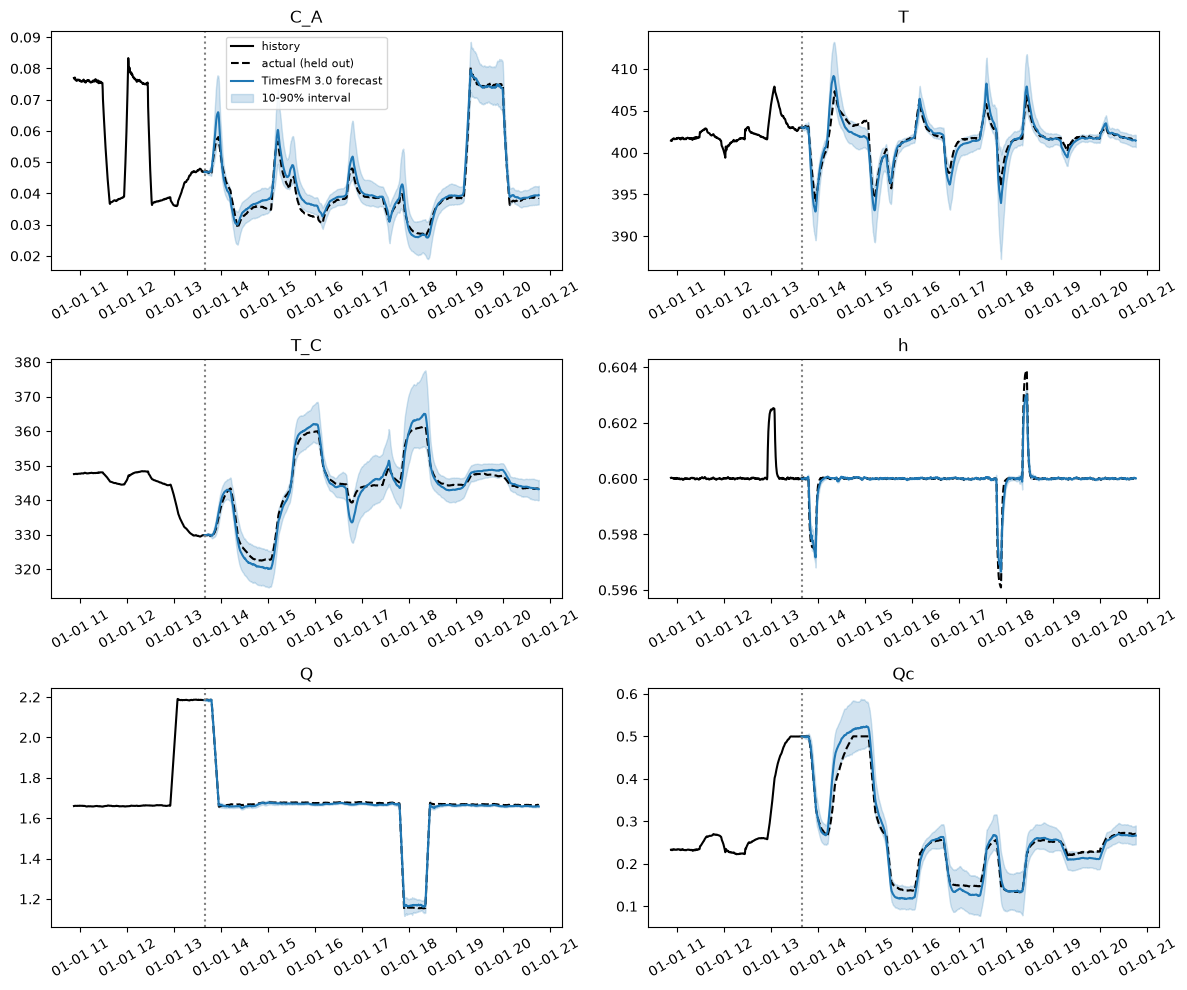

In [50]:
# %% Accuracy vs. the held-out actual simulation, and plots per state
for col in STATE_COLUMNS.values():
    sub = pred_df[pred_df["target_name"] == col].reset_index(drop=True)
    mae = np.mean(np.abs(sub["predictions"].values - truth_df[col].values))
    print(f"{col}: MAE = {mae:.5g}")

context_tail = context_df.iloc[-PLOT_LEAD_IN:]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for ax, col in zip(axes.ravel(), STATE_COLUMNS.values()):
    sub = pred_df[pred_df["target_name"] == col]
    ax.plot(context_tail["timestamp"], context_tail[col], color="black", label="history")
    ax.plot(truth_df["timestamp"], truth_df[col], color="black", linestyle="--", label="actual (held out)")
    ax.plot(sub["timestamp"], sub["predictions"], color="tab:blue", label="TimesFM 3.0 forecast")
    ax.fill_between(sub["timestamp"], sub["0.1"], sub["0.9"], color="tab:blue", alpha=0.2, label="10-90% interval")
    ax.axvline(truth_df["timestamp"].iloc[0], color="gray", linestyle=":")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
axes.ravel()[0].legend(fontsize=8)
fig.tight_layout()